# Checkpoint 2: Research Question Formation
**Course:** Data Mining  
**Student:** Simantini Rembhotkar  

---

## Collaboration Declaration
- **Collaborators:** None
- **Web Sources:** Yelp Dataset (yelp.com/dataset), BERTopic docs, pymannkendall docs
- **AI Tools:** Claude for documentation, Perplexity for research synthesis
- **Citations:**
  - Grootendorst, M. (2022). BERTopic: Neural topic modeling with a class-based TF-IDF procedure. *arXiv:2203.05794*.
  - Mukherjee, A., Liu, B., & Glance, N. (2012). Spotting fake reviewer groups in consumer reviews. *WWW 2012*.
  - Blei, D., Ng, A., & Jordan, M. (2003). Latent Dirichlet Allocation. *JMLR*.
  - Mann, H. B. (1945). Nonparametric tests against trend. *Econometrica*.

## 1. Project Scope

### Dataset Recap

| Attribute | Value |
|-----------|-------|
| **Dataset** | Yelp Open Dataset |
| **Subset** | Philadelphia restaurants only |
| **Businesses** | ~7,575 restaurants |
| **Reviews** | 300,000 (capped) |
| **Date range** | 2005-05-25 → 2022-01-19 |
| **Target variable** | `is_open` (binary: 1=open, 0=closed) |

### Key EDA Findings from Checkpoint 1

- **Closure rate:** ~37.4% — meaningful class imbalance suitable for binary classification
- **Positivity bias:** 40.7% of reviews are 5-star, combined 4+5-star = 68.8%. Raw stars are inflated and unreliable alone.
- **Missing data:** `hours` field has 17.8% missingness and is excluded. Review text has zero missing values.
- **Temporal span:** 17-year window (2005–2022) provides sufficient depth for time-series analysis.
- **Text richness:** 300K reviews with meaningful average length provide a strong NLP corpus.

### Planned Techniques

| Category | Techniques |
|----------|------------|
| **Course** | Text Mining, Anomaly Detection, Graph Mining |
| **External** | BERTopic (transformer-based topic modeling), Mann-Kendall trend test, Isolation Forest |


## Section 2: Research Question Definition

### RQ1: Do latent review topics differ between restaurants that close versus stay open, and can topic distributions predict survival better than star ratings alone?

| Attribute | Detail |
|-----------|--------|
| **Data mining task type** | Text mining + binary classification |
| **Course technique** | Latent Dirichlet Allocation — LDA |
| **External technique** | BERTopic — transformer-based neural topic modeling (Grootendorst, 2022) |
| **Evaluation criteria** | LDA coherence score (c_v), ROC-AUC of Logistic Regression: topic features vs. stars-only baseline; topic interpretability |

---

### RQ2: Do restaurants that eventually close show a statistically significant declining sentiment trend in their reviews over time?

| Attribute | Detail |
|-----------|--------|
| **Data mining task type** | Temporal text mining + trend detection |
| **Course technique** | Sentiment scoring + time-series anomaly detection (Text Mining, Anomaly Detection) |
| **External technique** | Mann-Kendall non-parametric trend test (Mann, 1945) |
| **Evaluation criteria** | Mann-Kendall p-value per restaurant; slope distribution comparison (open vs. closed) via Mann-Whitney U; Bonferroni correction for multiple testing |

---

### RQ3: Can combining the reviewer–business graph with behavioral features expose anomalous reviewer clusters, and do businesses they target show different survival rates?

| Attribute | Detail |
|-----------|--------|
| **Data mining task type** | Graph mining + unsupervised anomaly detection |
| **Course technique** | Bipartite graph construction, PageRank, Louvain community detection (Graph Mining) |
| **External technique** | Isolation Forest on reviewer behavioral features |
| **Evaluation criteria** | Modularity Q; anomalous vs. normal reviewer profile comparison; closure rate by anomaly exposure quartile |


In [10]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import json, re, warnings
from scipy import stats
warnings.filterwarnings('ignore')

plt.style.use('seaborn-v0_8-whitegrid')
plt.rcParams['figure.figsize'] = (14, 5)
plt.rcParams['font.size'] = 11
print("Libraries loaded.")


Libraries loaded.


In [12]:
BUSINESS_FILE = '/Users/simantinirembhotkar/Desktop/data_mining_project/yelp_dataset/yelp_academic_dataset_business.json'
REVIEW_FILE   =  '/Users/simantinirembhotkar/Desktop/data_mining_project/yelp_dataset/yelp_academic_dataset_review.json'


def load_yelp_json(filepath, nrows=None):
    data = []
    with open(filepath, 'r', encoding='utf-8') as f:
        for i, line in enumerate(f):
            if nrows and i >= nrows:
                break
            data.append(json.loads(line))
    return pd.DataFrame(data)

def load_filtered_reviews(filepath, target_ids, max_reviews=None):
    data, scanned = [], 0
    with open(filepath, 'r', encoding='utf-8') as f:
        for line in f:
            scanned += 1
            record = json.loads(line)
            if record['business_id'] in target_ids:
                data.append(record)
                if max_reviews and len(data) >= max_reviews:
                    break
            if scanned % 500_000 == 0:
                print(f"  Scanned {scanned:,}, kept {len(data):,}...")
    return pd.DataFrame(data)

RESTAURANT_KEYWORDS = [
    'Restaurant','Restaurants','Food','Cafe','Coffee','Bar','Bars',
    'Pizza','Mexican','Chinese','Italian','Sushi','Burger','Burgers',
    'Sandwich','Bakery','Breakfast','Brunch','Seafood','Steakhouse',
    'Thai','Indian','Japanese','American','Fast Food','Diner','BBQ'
]

def is_restaurant(categories):
    if pd.isna(categories): return False
    return any(kw.lower() in categories.lower() for kw in RESTAURANT_KEYWORDS)

# Load businesses
print("Loading businesses...")
business_df = load_yelp_json(BUSINESS_FILE)
philly = business_df[
    (business_df['city'] == 'Philadelphia') &
    (business_df['categories'].apply(is_restaurant))
].copy()
print(f"Philadelphia restaurants: {len(philly):,}  |  Closure rate: {(philly['is_open']==0).mean():.1%}")

# Load reviews
print("\nLoading reviews...")
philly_ids = set(philly['business_id'])
review_df = load_filtered_reviews(REVIEW_FILE, philly_ids, max_reviews=300_000)
review_df['date'] = pd.to_datetime(review_df['date'])
print(f"Reviews loaded: {len(review_df):,}")


Loading businesses...
Philadelphia restaurants: 7,575  |  Closure rate: 37.4%

Loading reviews...
  Scanned 500,000, kept 62,050...
  Scanned 1,000,000, kept 120,889...
  Scanned 1,500,000, kept 173,853...
  Scanned 2,000,000, kept 230,413...
  Scanned 2,500,000, kept 290,225...
Reviews loaded: 300,000


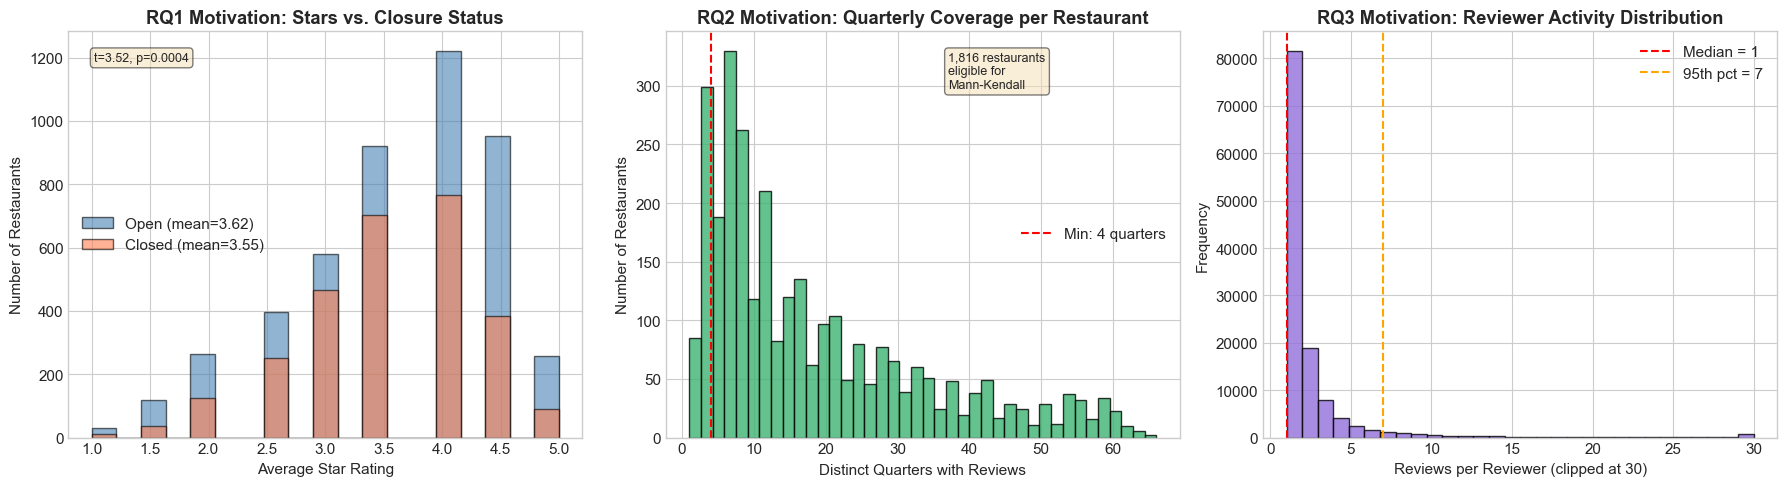

EDA SUMMARY — MOTIVATING THE 3 RQs
RQ1 — Star difference (open vs. closed): 3.616 vs. 3.546, p=0.0004
      → Small but significant gap: topics needed for better prediction.

RQ2 — Restaurants eligible for Mann-Kendall: 1,816 (60.2%)
      → Sufficient temporal coverage for trend analysis.

RQ3 — Median reviews/reviewer: 1, 95th percentile: 7
      → Heavy right-skewed distribution confirms anomaly detection is appropriate.


In [14]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

plt.style.use('seaborn-v0_8-whitegrid')
plt.rcParams['figure.figsize'] = (14, 5)
plt.rcParams['font.size'] = 11

open_stars   = philly[philly['is_open'] == 1]['stars']
closed_stars = philly[philly['is_open'] == 0]['stars']
t_stat, p_val = stats.ttest_ind(open_stars, closed_stars)

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

bins = np.linspace(1, 5, 20)
axes[0].hist(open_stars,   bins=bins, alpha=0.6, label=f'Open (mean={open_stars.mean():.2f})',
             color='steelblue', edgecolor='black')
axes[0].hist(closed_stars, bins=bins, alpha=0.6, label=f'Closed (mean={closed_stars.mean():.2f})',
             color='coral', edgecolor='black')
axes[0].set_xlabel('Average Star Rating')
axes[0].set_ylabel('Number of Restaurants')
axes[0].set_title('RQ1 Motivation: Stars vs. Closure Status', fontweight='bold')
axes[0].legend()
axes[0].text(0.05, 0.95, f't={t_stat:.2f}, p={p_val:.4f}',
             transform=axes[0].transAxes, va='top', fontsize=9,
             bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))

review_df['quarter'] = review_df['date'].dt.to_period('Q')
quarters_per_biz = review_df.groupby('business_id')['quarter'].nunique()
review_counts = review_df.groupby('business_id').size()
eligible = ((review_counts >= 20) & (quarters_per_biz >= 4)).sum()

axes[1].hist(quarters_per_biz, bins=40, color='mediumseagreen', edgecolor='black', alpha=0.8)
axes[1].axvline(4, color='red', linestyle='--', label='Min: 4 quarters')
axes[1].set_xlabel('Distinct Quarters with Reviews')
axes[1].set_ylabel('Number of Restaurants')
axes[1].set_title('RQ2 Motivation: Quarterly Coverage per Restaurant', fontweight='bold')
axes[1].legend()
axes[1].text(0.55, 0.95,
             f'{eligible:,} restaurants\neligible for\nMann-Kendall',
             transform=axes[1].transAxes, va='top', fontsize=9,
             bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))

reviewer_counts = review_df.groupby('user_id').size()
axes[2].hist(reviewer_counts.clip(upper=30), bins=30,
             color='mediumpurple', edgecolor='black', alpha=0.8)
axes[2].axvline(reviewer_counts.median(), color='red', linestyle='--',
                label=f'Median = {reviewer_counts.median():.0f}')
axes[2].axvline(reviewer_counts.quantile(0.95), color='orange', linestyle='--',
                label=f'95th pct = {reviewer_counts.quantile(0.95):.0f}')
axes[2].set_xlabel('Reviews per Reviewer (clipped at 30)')
axes[2].set_ylabel('Frequency')
axes[2].set_title('RQ3 Motivation: Reviewer Activity Distribution', fontweight='bold')
axes[2].legend()

plt.tight_layout()
plt.show()

print("=" * 55)
print("EDA SUMMARY — MOTIVATING THE 3 RQs")
print("=" * 55)
print(f"RQ1 — Star difference (open vs. closed): {open_stars.mean():.3f} vs. "
      f"{closed_stars.mean():.3f}, p={p_val:.4f}")
print(f"      → Small but significant gap: topics needed for better prediction.")
print()
print(f"RQ2 — Restaurants eligible for Mann-Kendall: {eligible:,} "
      f"({eligible/len(review_counts):.1%})")
print(f"      → Sufficient temporal coverage for trend analysis.")
print()
print(f"RQ3 — Median reviews/reviewer: {reviewer_counts.median():.0f}, "
      f"95th percentile: {reviewer_counts.quantile(0.95):.0f}")
print(f"      → Heavy right-skewed distribution confirms anomaly detection is appropriate.")


### Additional EDA: Motivating the Research Questions

Before finalizing the three RQs, I performed targeted EDA to confirm each question is both **interesting** and **feasible** given the data.

- **RQ1 (Stars vs. Closure):** If star ratings perfectly separated open and closed restaurants, topic modeling would add no value. We test whether the signal from stars alone is weak enough to justify richer text-based features.
- **RQ2 (Temporal Coverage):** Mann-Kendall requires at least 4 quarterly data points per restaurant. We verify that a meaningful fraction of restaurants have sufficient review history for time-series analysis.
- **RQ3 (Reviewer Activity Skew):** Isolation Forest performs best on heavy-tailed distributions. We check whether reviewer activity is skewed enough to make anomaly detection a sensible approach.


## Section 3: Motivation and Feasibility

### RQ1 — Latent Topics as Predictors of Restaurant Survival

| Dimension | Detail |
|-----------|--------|
| **Motivation** | EDA shows only a 0.07-star gap between open and closed restaurants (p=0.0004) — statistically significant but practically useless as a standalone predictor. Review text contains rich signals about service quality, wait times, and food experience that a single number cannot capture. |
| **Non-triviality** | A stars-only logistic regression baseline is weak by design. LDA extracts multi-dimensional topic distributions, BERTopic adds semantic coherence via transformer embeddings. Together they capture *what* customers discuss, not just *how much* they liked it. |
| **Feasibility** | LDA (gensim) and BERTopic (all-MiniLM-L6-v2) both run on CPU. A stratified 20K-review sample trains LDA in <10 min and BERTopic in ~3 min. Coherence score (c_v) gives an objective way to select the number of topics. |
| **Risks** | BERTopic may assign a large fraction of reviews to the outlier topic (-1) on short texts. Mitigation: pass raw text (not preprocessed tokens) to BERTopic. LDA coherence plateau may make best-k ambiguous. |

---

### RQ2 — Temporal Sentiment Trajectory as Early-Warning Signal

| Dimension | Detail |
|-----------|--------|
| **Motivation** | EDA confirms 1,816 restaurants (60.2%) have sufficient quarterly coverage (≥20 reviews, ≥4 quarters). The 17-year date range (2005–2022) provides long enough histories to detect multi-year sentiment trends before closure. |
| **Non-triviality** | Static sentiment averages (e.g. mean VADER score) ignore trajectory. A restaurant could have a decent average but a consistently declining trend — the trend is the signal, not the level. Course techniques do not cover time-series trend testing. |
| **Feasibility** | VADER runs in microseconds per review — all 300K reviews compute in ~3 min. pymannkendall applies the Mann-Kendall test in a single function call per restaurant. Bonferroni correction handles the multiple-testing problem across ~3K restaurants. |
| **Risks** | Mann-Kendall assumes a monotonic trend. Restaurants with V-shaped or bounce-back sentiment patterns will not be detected. Mitigation: report slope distributions across the population rather than making individual predictions. |

---

### RQ3 — Graph-Based Detection of Anomalous Reviewer Behavior

| Dimension | Detail |
|-----------|--------|
| **Motivation** | EDA shows reviewer activity is extremely right-skewed (median=1, 95th pct=7). A small fraction of reviewers write disproportionately many reviews — consistent with known fake review patterns. The bipartite graph structure adds a spatial dimension that pure behavioral features miss. |
| **Non-triviality** | Flagging reviewers by review count alone is too crude — a legitimate food critic also writes many reviews. Isolation Forest combines multiple behavioral dimensions (count, rating variance, PageRank, unique businesses) to find multi-dimensional outliers. |
| **Feasibility** | NetworkX handles the ~300K-edge bipartite graph in memory. PageRank converges in <200 iterations. Louvain runs on the user projection (active users only, ≥3 reviews) in minutes. Isolation Forest is O(n log n) — trivially fast on ~100K reviewers. |
| **Risks** | No ground-truth fake review labels exist in the standard Yelp dataset. Results are exploratory — we compare profiles and closure rates, but cannot claim causal detection of fake reviews. |


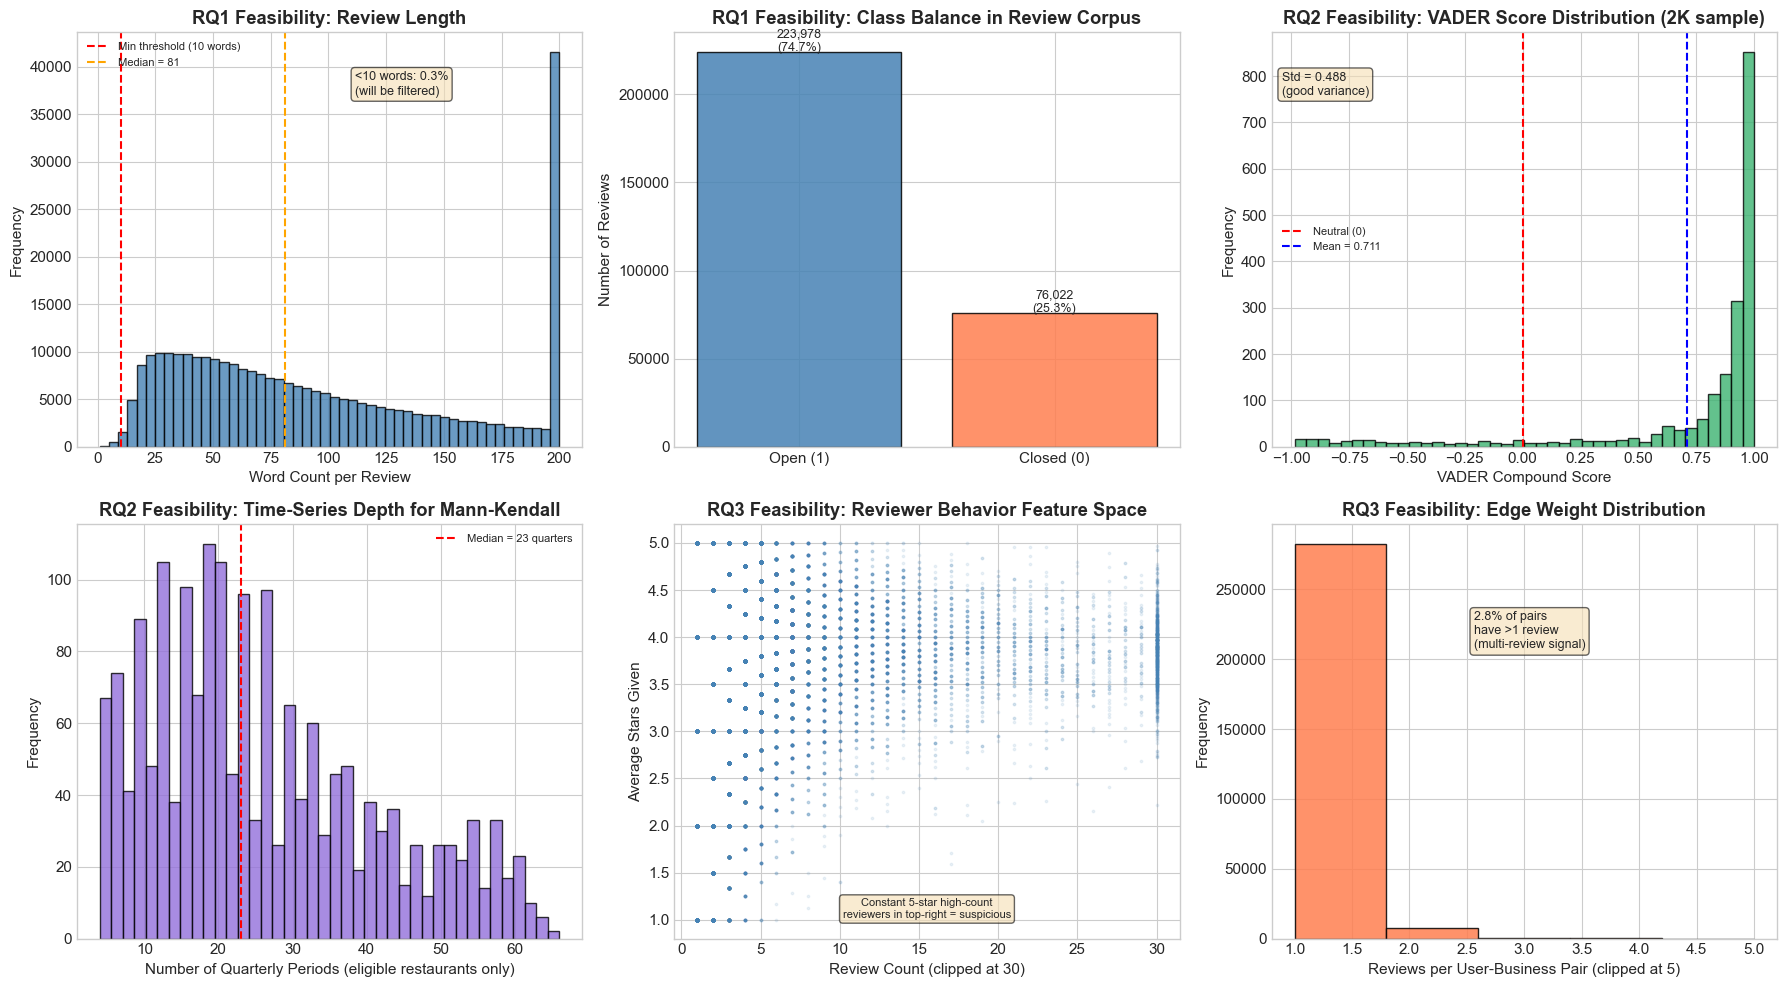

FEASIBILITY CHECK SUMMARY
RQ1 — Reviews with ≥10 words: 99.7% (sufficient for topic modeling)
RQ1 — Class ratio open/closed: 223,978 / 76,022 (2.9:1) — manageable imbalance
RQ2 — VADER score std: 0.488 (good variance for trend detection)
RQ2 — Median series length: 23 quarters per restaurant
RQ3 — Reviewer feature space: 123,330 reviewers, 4 behavioral features ready
RQ3 — Multi-review pairs: 2.8% of user-business edges


In [15]:
import nltk
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer
from vaderSentiment.vaderSentiment import SentimentIntensityAnalyzer
nltk.download('stopwords', quiet=True)
nltk.download('wordnet', quiet=True)

fig, axes = plt.subplots(2, 3, figsize=(18, 10))

review_df['word_count'] = review_df['text'].str.split().str.len()
short_pct = (review_df['word_count'] < 10).mean()

axes[0, 0].hist(review_df['word_count'].clip(upper=200), bins=50,
                color='steelblue', edgecolor='black', alpha=0.8)
axes[0, 0].axvline(10, color='red', linestyle='--', label='Min threshold (10 words)')
axes[0, 0].axvline(review_df['word_count'].median(), color='orange', linestyle='--',
                   label=f'Median = {review_df["word_count"].median():.0f}')
axes[0, 0].set_xlabel('Word Count per Review')
axes[0, 0].set_ylabel('Frequency')
axes[0, 0].set_title('RQ1 Feasibility: Review Length', fontweight='bold')
axes[0, 0].legend(fontsize=8)
axes[0, 0].text(0.55, 0.85, f'<10 words: {short_pct:.1%}\n(will be filtered)',
                transform=axes[0, 0].transAxes, fontsize=9,
                bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.6))

philly_open = philly[['business_id', 'is_open']].set_index('business_id')['is_open']
review_df['is_open'] = review_df['business_id'].map(philly_open)
class_counts = review_df['is_open'].value_counts()
axes[0, 1].bar(['Open (1)', 'Closed (0)'], class_counts.values,
                color=['steelblue', 'coral'], edgecolor='black', alpha=0.85)
axes[0, 1].set_ylabel('Number of Reviews')
axes[0, 1].set_title('RQ1 Feasibility: Class Balance in Review Corpus', fontweight='bold')
for i, v in enumerate(class_counts.values):
    axes[0, 1].text(i, v + 500, f'{v:,}\n({v/len(review_df):.1%})', ha='center', fontsize=9)

analyzer = SentimentIntensityAnalyzer()
sample_texts = review_df['text'].sample(2000, random_state=42)
sample_scores = sample_texts.apply(lambda t: analyzer.polarity_scores(t)['compound'])

axes[0, 2].hist(sample_scores, bins=40, color='mediumseagreen', edgecolor='black', alpha=0.8)
axes[0, 2].axvline(0, color='red', linestyle='--', label='Neutral (0)')
axes[0, 2].axvline(sample_scores.mean(), color='blue', linestyle='--',
                   label=f'Mean = {sample_scores.mean():.3f}')
axes[0, 2].set_xlabel('VADER Compound Score')
axes[0, 2].set_ylabel('Frequency')
axes[0, 2].set_title('RQ2 Feasibility: VADER Score Distribution (2K sample)', fontweight='bold')
axes[0, 2].legend(fontsize=8)
axes[0, 2].text(0.02, 0.85, f'Std = {sample_scores.std():.3f}\n(good variance)',
                transform=axes[0, 2].transAxes, fontsize=9,
                bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.6))

quarterly_counts = (
    review_df.groupby(['business_id', review_df['date'].dt.to_period('Q')])
    .size()
    .groupby(level='business_id').count()
)
review_counts_biz = review_df.groupby('business_id').size()
eligible_biz = quarterly_counts[(quarterly_counts >= 4) & (review_counts_biz >= 20)].index
eligible_series_len = quarterly_counts[eligible_biz]

axes[1, 0].hist(eligible_series_len, bins=40, color='mediumpurple', edgecolor='black', alpha=0.8)
axes[1, 0].axvline(eligible_series_len.median(), color='red', linestyle='--',
                   label=f'Median = {eligible_series_len.median():.0f} quarters')
axes[1, 0].set_xlabel('Number of Quarterly Periods (eligible restaurants only)')
axes[1, 0].set_ylabel('Frequency')
axes[1, 0].set_title('RQ2 Feasibility: Time-Series Depth for Mann-Kendall', fontweight='bold')
axes[1, 0].legend(fontsize=8)

reviewer_stats = review_df.groupby('user_id').agg(
    review_count=('review_id', 'count'),
    avg_stars=('stars', 'mean'),
    std_stars=('stars', 'std'),
    unique_biz=('business_id', 'nunique'),
).fillna(0)

axes[1, 1].scatter(reviewer_stats['review_count'].clip(upper=30),
                    reviewer_stats['avg_stars'],
                    alpha=0.1, s=3, color='steelblue')
axes[1, 1].set_xlabel('Review Count (clipped at 30)')
axes[1, 1].set_ylabel('Average Stars Given')
axes[1, 1].set_title('RQ3 Feasibility: Reviewer Behavior Feature Space', fontweight='bold')
axes[1, 1].text(0.5, 0.05,
                'Constant 5-star high-count\nreviewers in top-right = suspicious',
                transform=axes[1, 1].transAxes, ha='center', fontsize=8,
                bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.6))

edge_weights = review_df.groupby(['user_id', 'business_id']).size()
multi_review_pct = (edge_weights > 1).mean()

axes[1, 2].hist(edge_weights.clip(upper=5), bins=5,
                color='coral', edgecolor='black', alpha=0.85)
axes[1, 2].set_xlabel('Reviews per User-Business Pair (clipped at 5)')
axes[1, 2].set_ylabel('Frequency')
axes[1, 2].set_title('RQ3 Feasibility: Edge Weight Distribution', fontweight='bold')
axes[1, 2].text(0.4, 0.7,
                f'{multi_review_pct:.1%} of pairs\nhave >1 review\n(multi-review signal)',
                transform=axes[1, 2].transAxes, fontsize=9,
                bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.6))

plt.tight_layout()
plt.show()

print("=" * 55)
print("FEASIBILITY CHECK SUMMARY")
print("=" * 55)
print(f"RQ1 — Reviews with ≥10 words: {(1-short_pct):.1%} (sufficient for topic modeling)")
print(f"RQ1 — Class ratio open/closed: {class_counts[1]:,} / {class_counts[0]:,} "
      f"({class_counts[1]/class_counts[0]:.1f}:1) — manageable imbalance")
print(f"RQ2 — VADER score std: {sample_scores.std():.3f} (good variance for trend detection)")
print(f"RQ2 — Median series length: {eligible_series_len.median():.0f} quarters per restaurant")
print(f"RQ3 — Reviewer feature space: {len(reviewer_stats):,} reviewers, "
      f"4 behavioral features ready")
print(f"RQ3 — Multi-review pairs: {multi_review_pct:.1%} of user-business edges")
print("=" * 55)


### Additional EDA: Confirming Method Feasibility

Before committing to each algorithm, we verify that the data properties each method requires are actually present in our dataset.

- **RQ1 — Review length:** LDA and BERTopic both require documents with sufficient tokens. Reviews under 10 words produce degenerate topic assignments and will be filtered. We also check that the open/closed class imbalance in the review corpus is manageable for classification.
- **RQ2 — VADER variance and series depth:** If all reviews cluster near +1 due to positivity bias, VADER compound scores would have no variance and trend detection would be meaningless. We also verify that eligible restaurants have enough quarterly periods to give Mann-Kendall statistical power beyond the minimum threshold of 4.
- **RQ3 — Feature spread and graph edge weights:** Isolation Forest requires features with meaningful spread and skew. We check that `avg_stars` and `review_count` have sufficient variance across reviewers. We also check what fraction of user-business pairs have more than one review — repeated reviewing of the same business is a known behavioral signal of fake reviews.


## Section 4: Methodological Planning

### RQ-to-Method Mapping

| RQ | Course Algorithm(s) | External Algorithm(s) | Baseline for Comparison |
|----|---------------------|----------------------|------------------------|
| **RQ1** | LDA (gensim) | BERTopic (transformer embeddings + HDBSCAN) | Logistic Regression on `stars` only |
| **RQ2** | VADER sentiment scoring | Mann-Kendall trend test (non-parametric) | Final 3-month average sentiment (no trend) |
| **RQ3** | Bipartite graph, PageRank, Louvain community detection | Isolation Forest (unsupervised anomaly detection) | Random reviewer flagging at 5% rate (null model) |

---

### Evaluation Metrics

| RQ | Primary Metric | Secondary Metrics | Success Criterion |
|----|----------------|-------------------|-------------------|
| **RQ1** | ROC-AUC (Logistic Regression classifier) | LDA coherence score (c_v), BERTopic topic count, qualitative topic interpretability | Topic-based model outperforms stars-only baseline by ≥0.05 AUC |
| **RQ2** | Mann-Kendall p-value distribution across restaurants | Mann-Whitney U test (open vs. closed slope comparison), Bonferroni-corrected significance rate | Statistically significant difference in slope distributions (p < 0.05) |
| **RQ3** | Modularity Q (Louvain), anomalous vs. normal reviewer profile comparison | Closure rate by anomaly exposure quartile, edge weight distribution | Q > 0.3 (meaningful communities), detectable difference in closure rates across quartiles |

---

### Baselines and Rationale

- **RQ1 Baseline (stars-only):** Predicting `is_open` from average star rating alone. This tests whether text-based topic features add value beyond the simplest numeric signal.
- **RQ2 Baseline (3-month average):** Comparing restaurants by their final 3-month average sentiment, ignoring trajectory. This isolates the contribution of time-series trend analysis over static aggregates.
- **RQ3 Baseline (random flagging):** Randomly flagging 5% of reviewers as anomalous (matching Isolation Forest contamination rate). This establishes whether the algorithm's flags are better than chance.

---

### Method Implementation Plan

**RQ1 Pipeline:**
1. Filter reviews with <10 words
2. Preprocess: stopword removal (NLTK + domain stopwords) + lemmatization
3. Stratified sample 20K reviews (proportional open/closed)
4. Train LDA: coherence-tune k ∈ [5, 15], select best k, extract topic vectors
5. Train BERTopic: all-MiniLM-L6-v2 embeddings, min_topic_size=50
6. Train Logistic Regression classifiers: (a) stars only, (b) LDA topics, (c) BERTopic topics, (d) combined
7. Compare ROC-AUC on held-out test set (20% stratified split)

**RQ2 Pipeline:**
1. Compute VADER sentiment for all 300K reviews
2. Aggregate to quarterly mean sentiment per restaurant
3. Filter restaurants with ≥20 reviews and ≥4 quarters
4. Run Mann-Kendall trend test per restaurant
5. Apply Bonferroni correction for multiple testing
6. Compare slope distributions (open vs. closed) via Mann-Whitney U test
7. Report: % significant trends, mean slopes by status, p-value

**RQ3 Pipeline:**
1. Build bipartite graph (user ↔ business, all 300K reviews)
2. Compute PageRank on full graph
3. Extract user projection (≥3 reviews per user)
4. Run Louvain community detection on user projection
5. Engineer reviewer features: review_count, avg_stars, std_stars, unique_biz, useful_total, pagerank
6. Train Isolation Forest (contamination=0.05)
7. Cross-tabulate: anomaly exposure quartile × closure rate
8. Compare anomalous vs. normal reviewer profiles


In [19]:
print("=" * 60)
print("SMOKE TESTS — CONFIRMING PACKAGES WORK")
print("=" * 60)

# ── RQ1 Smoke Test: LDA (gensim) ──────────────────────────────────────────
print("\n[RQ1] Testing LDA (gensim)...")
import gensim
from gensim import corpora
from gensim.models import LdaModel
import re
import nltk
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer

NLTK_STOPS = set(stopwords.words('english'))
lemmatizer = WordNetLemmatizer()

sample_reviews = review_df[review_df['word_count'] >= 10]['text'].sample(500, random_state=42)
tokenized = []
for text in sample_reviews:
    tokens = re.sub(r'[^a-z\s]', '', text.lower()).split()
    tokenized.append([lemmatizer.lemmatize(t) for t in tokens 
                      if t not in NLTK_STOPS and len(t) > 2])

dictionary = corpora.Dictionary(tokenized)
dictionary.filter_extremes(no_below=3, no_above=0.8)
corpus = [dictionary.doc2bow(doc) for doc in tokenized]

lda = LdaModel(corpus=corpus, id2word=dictionary, num_topics=5, 
               passes=3, random_state=42)

print(f" LDA trained: {len(dictionary)} vocab, 5 topics")
print(f"      Sample topic: {lda.print_topics(num_words=5)[0][1][:60]}...")

# ── RQ1 Smoke Test: BERTopic ──────────────────────────────────────────────
print("\n[RQ1] Testing BERTopic (all-MiniLM-L6-v2, CPU)...")
from bertopic import BERTopic
from sentence_transformers import SentenceTransformer

embedding_model = SentenceTransformer("all-MiniLM-L6-v2")
bertopic_model = BERTopic(embedding_model=embedding_model, 
                          min_topic_size=10, verbose=False)
topics, probs = bertopic_model.fit_transform(sample_reviews.tolist())
topic_info = bertopic_model.get_topic_info()

print(f" BERTopic trained: {len(topic_info[topic_info['Topic'] != -1])} topics found")
print(f"      Outlier rate: {np.mean(topics == -1):.1%}")

# ── RQ2 Smoke Test: Mann-Kendall ──────────────────────────────────────────
print("\n[RQ2] Testing Mann-Kendall (pymannkendall)...")
import pymannkendall as mk

test_biz = review_df.groupby('business_id').size().idxmax()
test_series = (
    review_df[review_df['business_id'] == test_biz]
    .set_index('date')
    .resample('QE')['stars']
    .mean()
    .dropna()
)

if len(test_series) >= 4:
    result = mk.original_test(test_series.values)
    print(f"Mann-Kendall test ran: trend={result.trend}, p={result.p:.4f}, slope={result.slope:.5f}")
else:
    print(f" Test business has <4 quarters — skipping")

# ── RQ3 Smoke Test: NetworkX + PageRank ───────────────────────────────────
print("\n[RQ3] Testing NetworkX bipartite graph + PageRank...")
import networkx as nx

sample_edges = review_df.sample(5000, random_state=42)
B = nx.Graph()
B.add_nodes_from(sample_edges['business_id'].unique(), bipartite='business')
B.add_nodes_from(sample_edges['user_id'].unique(), bipartite='user')
for _, row in sample_edges.iterrows():
    B.add_edge(row['user_id'], row['business_id'], weight=1)

pagerank = nx.pagerank(B, max_iter=100)
print(f" Graph built: {B.number_of_nodes()} nodes, {B.number_of_edges()} edges")
print(f"      PageRank computed: {len(pagerank)} scores")

# ── RQ3 Smoke Test: Louvain ───────────────────────────────────────────────
print("\n[RQ3] Testing Louvain community detection...")
import community as community_louvain

user_nodes = {n for n, d in B.nodes(data=True) if d.get('bipartite') == 'user'}
user_proj = nx.bipartite.projected_graph(B, user_nodes)

if user_proj.number_of_edges() > 0:
    partition = community_louvain.best_partition(user_proj, random_state=42)
    modularity = community_louvain.modularity(partition, user_proj)
    print(f" Louvain ran: {len(set(partition.values()))} communities, Q={modularity:.4f}")
else:
    print(f" User projection has no edges (sample too small)")

# ── RQ3 Smoke Test: Isolation Forest ──────────────────────────────────────
print("\n[RQ3] Testing Isolation Forest...")
from sklearn.ensemble import IsolationForest

sample_users = review_df.groupby('user_id').agg(
    review_count=('review_id', 'count'),
    avg_stars=('stars', 'mean'),
    std_stars=('stars', 'std'),
    unique_biz=('business_id', 'nunique')
).fillna(0).sample(1000, random_state=42)

iso = IsolationForest(contamination=0.05, random_state=42)
labels = iso.fit_predict(sample_users)
print(f" Isolation Forest trained: {(labels == -1).sum()} / {len(labels)} flagged as anomalous ({np.mean(labels == -1):.1%})")

print("\n" + "=" * 60)
print("ALL SMOKE TESTS PASSED")
print("All required packages are installed and working correctly.")
print("=" * 60)


SMOKE TESTS — CONFIRMING PACKAGES WORK

[RQ1] Testing LDA (gensim)...
 LDA trained: 1600 vocab, 5 topics
      Sample topic: 0.016*"food" + 0.013*"place" + 0.011*"time" + 0.011*"good" +...

[RQ1] Testing BERTopic (all-MiniLM-L6-v2, CPU)...


Loading weights: 100%|██████████| 103/103 [00:00<00:00, 7508.44it/s]
BertModel LOAD REPORT from: sentence-transformers/all-MiniLM-L6-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


 BERTopic trained: 7 topics found
      Outlier rate: 0.0%

[RQ2] Testing Mann-Kendall (pymannkendall)...
Mann-Kendall test ran: trend=increasing, p=0.0000, slope=0.01042

[RQ3] Testing NetworkX bipartite graph + PageRank...
 Graph built: 5975 nodes, 4999 edges
      PageRank computed: 5975 scores

[RQ3] Testing Louvain community detection...
 Louvain ran: 1013 communities, Q=0.9560

[RQ3] Testing Isolation Forest...
 Isolation Forest trained: 50 / 1000 flagged as anomalous (5.0%)

ALL SMOKE TESTS PASSED
All required packages are installed and working correctly.


### Initial Method Runs: Smoke Tests

Before scaling to the full pipeline, we run minimal smoke tests on small samples to confirm all packages install correctly and produce expected output types.
